In [42]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [43]:
DATA_DIR = "../data"

bars_seen_train         = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_train.parquet"), engine="fastparquet")
bars_unseen_train       = pd.read_parquet(os.path.join(DATA_DIR, "bars_unseen_train.parquet"), engine="fastparquet")
bars_seen_public_test   = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_public_test.parquet"), engine="fastparquet")
bars_seen_private_test  = pd.read_parquet(os.path.join(DATA_DIR, "bars_seen_private_test.parquet"), engine="fastparquet")

headlines_seen_train        = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_train.parquet"), engine="fastparquet")
headlines_unseen_train      = pd.read_parquet(os.path.join(DATA_DIR, "headlines_unseen_train.parquet"), engine="fastparquet")
headlines_seen_public_test  = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_public_test.parquet"), engine="fastparquet")
headlines_seen_private_test = pd.read_parquet(os.path.join(DATA_DIR, "headlines_seen_private_test.parquet"), engine="fastparquet")

print("bars_seen_train:",         bars_seen_train.shape)
print("bars_unseen_train:",       bars_unseen_train.shape)
print("bars_seen_public_test:",   bars_seen_public_test.shape)
print("bars_seen_private_test:",  bars_seen_private_test.shape)
print("headlines_seen_train:",        headlines_seen_train.shape)
print("headlines_unseen_train:",      headlines_unseen_train.shape)
print("headlines_seen_public_test:",  headlines_seen_public_test.shape)
print("headlines_seen_private_test:", headlines_seen_private_test.shape)

bars_seen_train: (50000, 6)
bars_unseen_train: (50000, 6)
bars_seen_public_test: (500000, 6)
bars_seen_private_test: (500000, 6)
headlines_seen_train: (9740, 3)
headlines_unseen_train: (7631, 3)
headlines_seen_public_test: (99308, 3)
headlines_seen_private_test: (99148, 3)


In [44]:
# Concat bars_seen_train and bars_unseen_train
bars_seen_train = pd.concat([bars_seen_train, bars_unseen_train], ignore_index=True)
print("bars_seen_train:", bars_seen_train.shape)

print(bars_seen_train.head())
print(bars_seen_train.tail())

bars_seen_train: (100000, 6)
   bar_ix  session  open    high     low   close
0       0        0   1.0  1.0029  0.9986  0.9999
1       0        1   1.0  1.0024  0.9980  1.0011
2       0        2   1.0  1.0005  0.9952  0.9957
3       0        3   1.0  1.0008  0.9986  1.0008
4       0        4   1.0  1.0031  0.9996  1.0009
       bar_ix  session    open    high     low   close
99995      99      995  0.9833  0.9837  0.9811  0.9812
99996      99      996  1.0684  1.0685  1.0638  1.0661
99997      99      997  1.0058  1.0060  1.0019  1.0028
99998      99      998  1.0014  1.0033  1.0001  1.0028
99999      99      999  1.0324  1.0330  1.0308  1.0325


# Autocorrelation between retuns and bars seen

In [45]:
total_sessions = bars_seen_train["session"].nunique()
print(f"Total unique sessions in bars_seen_train: {total_sessions}")
# Looking at first 300 and plotting price over time

#open price 
open_price_df = bars_seen_train[["session", "bar_ix", "open"]]
open_price_df


Total unique sessions in bars_seen_train: 1000


,session,bar_ix,open
0,0,0,1.0000
1,1,0,1.0000
2,2,0,1.0000
3,3,0,1.0000
4,4,0,1.0000
...,...,...,...
99995,995,99,0.9833
99996,996,99,1.0684
99997,997,99,1.0058
99998,998,99,1.0014


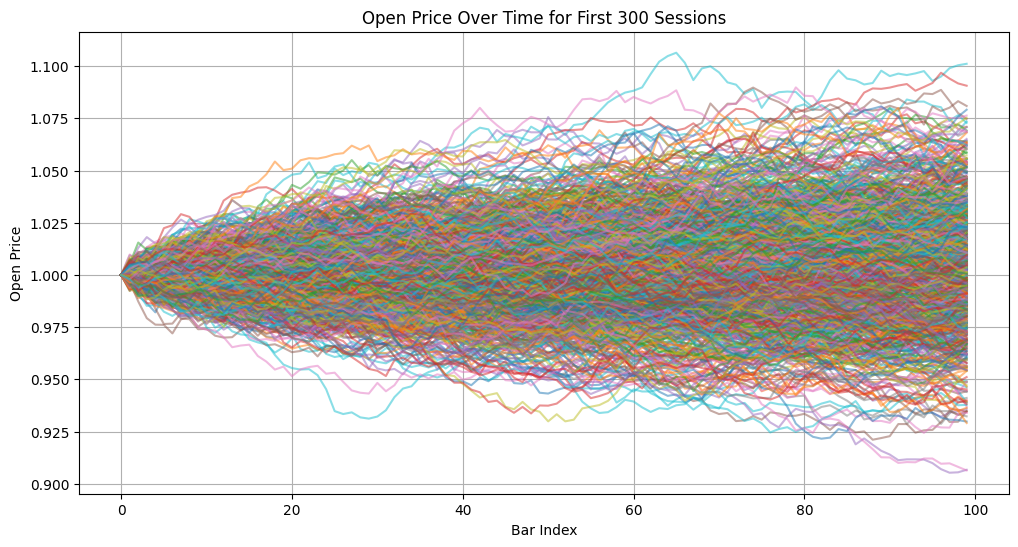

In [46]:
open_price_pivot = open_price_df.pivot(index="bar_ix", columns="session", values="open")
# plot the first 300 sessions
plt.figure(figsize=(12, 6))
for session in open_price_pivot.columns:
    plt.plot(open_price_pivot.index, open_price_pivot[session], alpha=0.5)
plt.title("Open Price Over Time for First 300 Sessions")
plt.xlabel("Bar Index")
plt.ylabel("Open Price")
plt.grid()
plt.show()



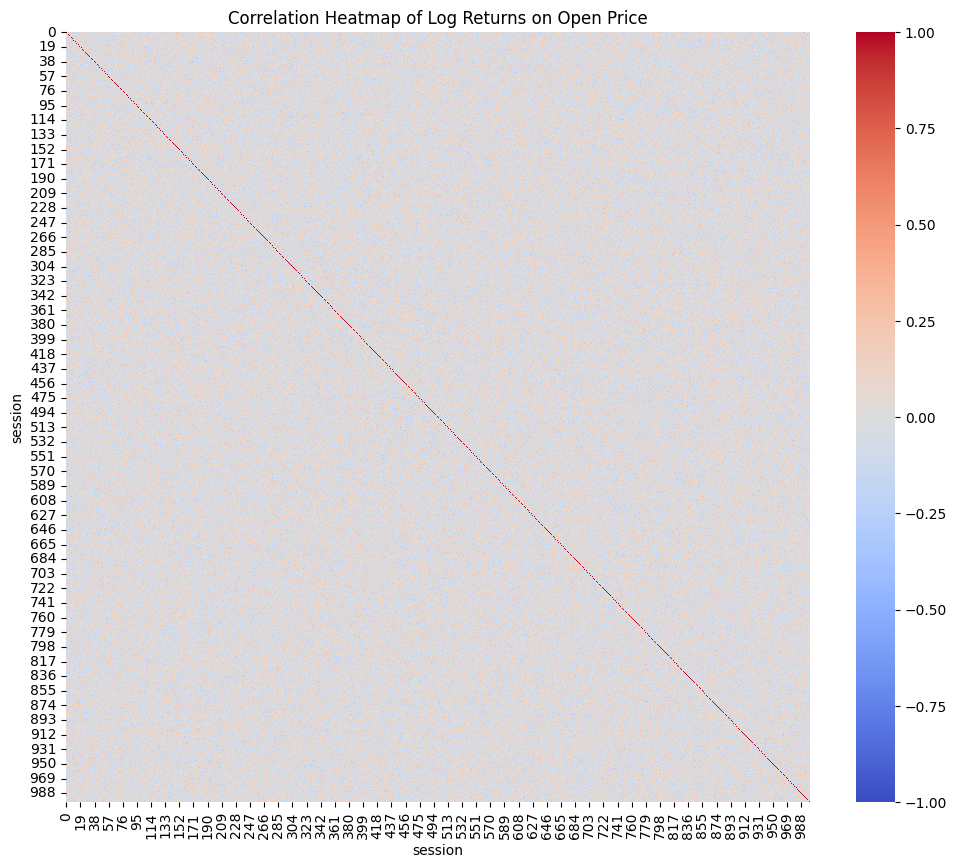

In [47]:
import seaborn as sns
# creating log returns on open price matrix 
log_ret_open = np.log(open_price_pivot / open_price_pivot.shift(1)).dropna()
# now plot a heat map of the log returns for correlation 
plt.figure(figsize=(12, 10))
sns.heatmap(log_ret_open.corr(), cmap="coolwarm", vmin=-1
, vmax=1)
plt.title("Correlation Heatmap of Log Returns on Open Price")
plt.show()

In [48]:
# look at how often the corr is greater that 0.1 for each session pair that is unique pair of sessions
corr_matrix = log_ret_open.corr()
# get the upper triangle of the correlation matrix without the diagonal
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1
).astype(bool))
# count how many pairs have correlation greater than 0.1
num_pairs_greater_than_0_1 = (upper_triangle > 0.3).sum().sum()
total_pairs = (upper_triangle.notna()).sum().sum()
print(f"Number of session pairs with correlation > 0.1: {num_pairs_greater_than_0_1}")
print(f"Total number of session pairs: {total_pairs}")
print(f"Percentage of session pairs with correlation > 0.1: {num_pairs_greater_than_0_1 / total_pairs * 100:.2f}%")


Number of session pairs with correlation > 0.1: 631
Total number of session pairs: 499500
Percentage of session pairs with correlation > 0.1: 0.13%


In [49]:
correlated_pairs = (
    upper_triangle
    .rename_axis(index="session_a", columns="session_b")
    .stack()
    .reset_index(name="correlation")
    .query("correlation > 0.3")
    .sort_values("correlation", ascending=False)
    .reset_index(drop=True)
)
print(f"Pairs with corr > 0.5: {len(correlated_pairs)}")
correlated_pairs

Pairs with corr > 0.5: 631


,session_a,session_b,correlation
0,155,400,0.480754
1,431,528,0.464115
2,282,967,0.450232
3,329,744,0.424410
4,572,868,0.418535
...,...,...,...
626,280,990,0.300117
627,344,604,0.300106
628,749,775,0.300094
629,87,765,0.300056


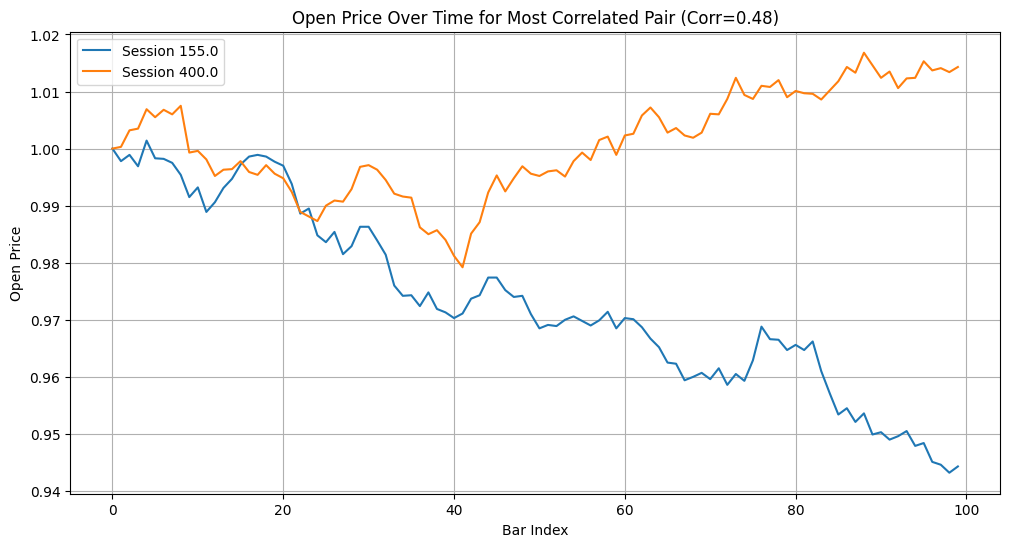

In [50]:
# Plot the price series for the most correlated pair
most_correlated_pair = correlated_pairs.iloc[0]
session_a = most_correlated_pair["session_a"]
session_b = most_correlated_pair["session_b"]
plt.figure(figsize=(12, 6))
plt.plot(open_price_pivot.index, open_price_pivot[session_a], label=f"Session {session_a}")
plt.plot(open_price_pivot.index, open_price_pivot[session_b], label=f"Session {session_b}")
plt.title(f"Open Price Over Time for Most Correlated Pair (Corr={most_correlated_pair['correlation']:.2f})")
plt.xlabel("Bar Index")
plt.ylabel("Open Price")
plt.legend()
plt.grid()
plt.show()

In [51]:
# look at companies with largest and smallest average high - low spread and open - close spread
bars_seen_train["high_low_spread"] = bars_seen_train["high"] - bars_seen_train["low"]
bars_seen_train["open_close_spread"] = bars_seen_train["open"] - bars_seen_train["close"]
# group by session and get the average spread for each session
session_spreads = bars_seen_train.groupby("session").agg({
    "high_low_spread": "mean",
    "open_close_spread": "mean"
}).reset_index()
# get the top 5 sessions with largest average high - low spread
top_high_low_spread = session_spreads.sort_values("high_low_spread", ascending=False).head(5)
print("Top 5 sessions with largest average high - low spread:")
print(top_high_low_spread[["session", "high_low_spread"]])
# get the top 5 sessions with smallest average high - low spread
bottom_high_low_spread = session_spreads.sort_values("high_low_spread", ascending=True).head(5)
print("Top 5 sessions with smallest average high - low spread:")
print(bottom_high_low_spread[["session", "high_low_spread"]])
# get the top 5 sessions with largest average open - close spread
top_open_close_spread = session_spreads.sort_values("open_close_spread", ascending=False).head(5)
print("Top 5 sessions with largest average open - close spread:")
print(top_open_close_spread[["session", "open_close_spread"]])
# get the top 5 sessions with smallest average open - close spread
bottom_open_close_spread = session_spreads.sort_values("open_close_spread", ascending=True).head(5)
print("Top 5 sessions with smallest average open - close spread:")
print(bottom_open_close_spread[["session", "open_close_spread"]])

Top 5 sessions with largest average high - low spread:
     session  high_low_spread
209      209         0.005559
80        80         0.005461
576      576         0.005394
447      447         0.005326
356      356         0.005316
Top 5 sessions with smallest average high - low spread:
     session  high_low_spread
304      304         0.002591
252      252         0.002632
752      752         0.002677
936      936         0.002690
279      279         0.002690
Top 5 sessions with largest average open - close spread:
     session  open_close_spread
444      444           0.001024
946      946           0.000889
581      581           0.000729
106      106           0.000700
219      219           0.000687
Top 5 sessions with smallest average open - close spread:
     session  open_close_spread
49        49          -0.000995
303      303          -0.000896
549      549          -0.000805
780      780          -0.000780
884      884          -0.000773


Sessions containing 'Zelval Energy': [  2   4  32  38  56  59  65 109 117 159 183 194 204 224 230 254 276 329
 344 345 350 357 373 387 400 446 472 473 475 496 517 556 559 583 599 611
 622 629 648 671 672 679 690 705 728 751 790 792 820 836 873 875 895 897
 901 905 914 926]


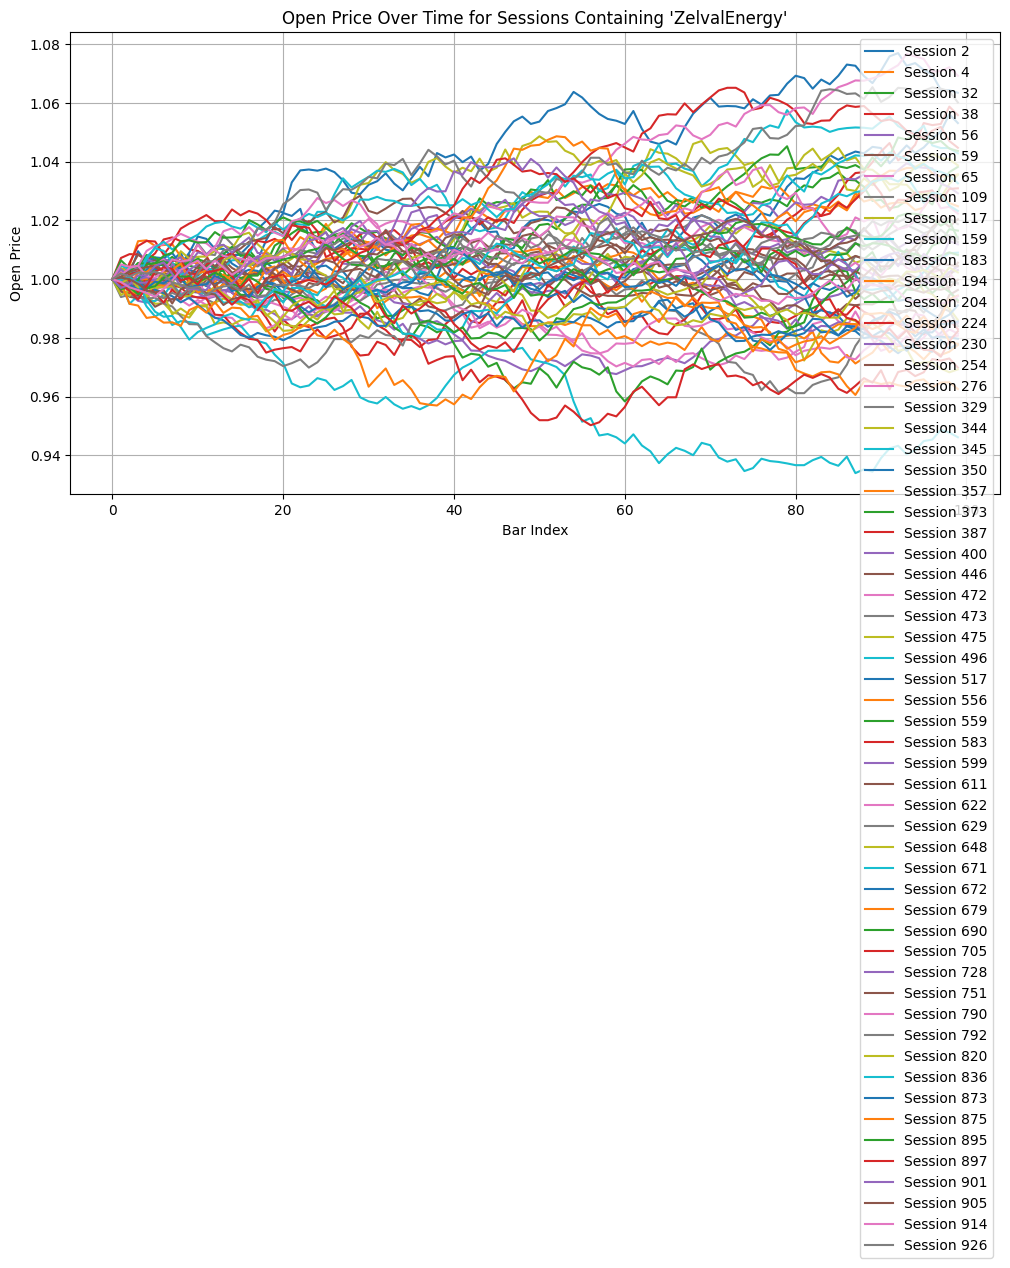

In [52]:
headlines_seen_train.head()
# Find all sessions that contain "ZelvalEnergy" in the headline and plot their open price series
zelval_sessions = headlines_seen_train[headlines_seen_train["headline"].str.contains("Zelval Energy", case=False, na=False)]["session"].unique()
print(f"Sessions containing 'Zelval Energy': {zelval_sessions}")
plt.figure(figsize=(12, 6))
for session in zelval_sessions:
    plt.plot(open_price_pivot.index, open_price_pivot[session], label=f"Session {session}")
plt.title("Open Price Over Time for Sessions Containing 'ZelvalEnergy'")
plt.xlabel("Bar Index")
plt.ylabel("Open Price")
plt.legend()
plt.grid()
plt.show()

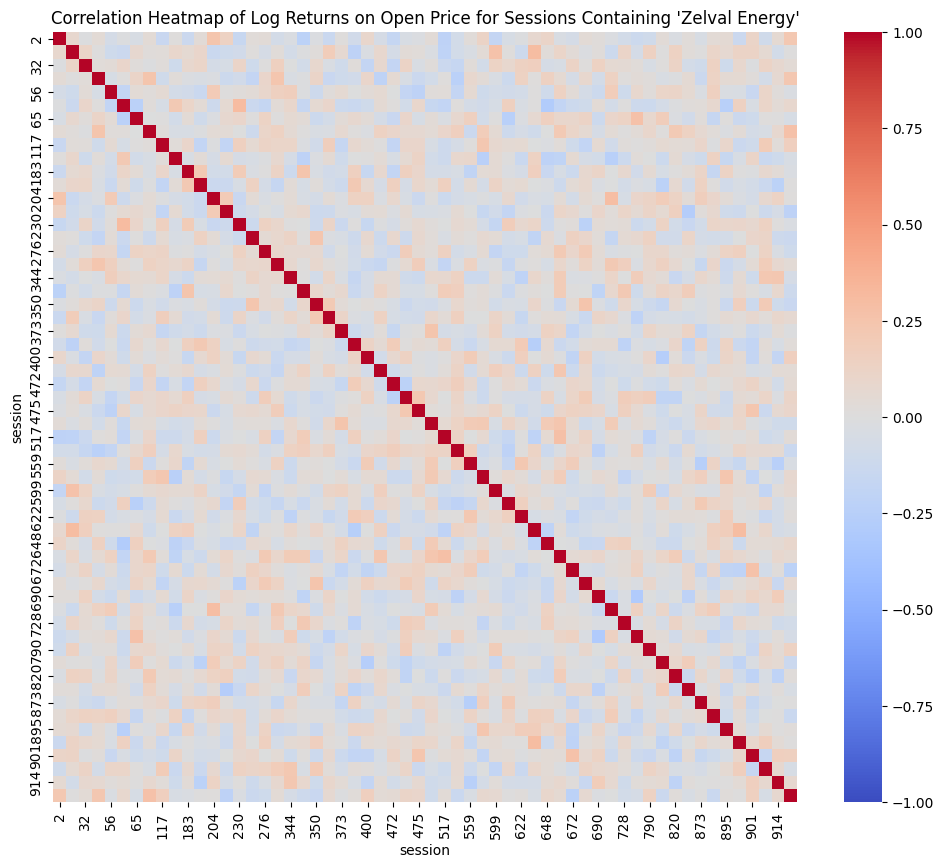

In [53]:
# look at correlation only for sessions that contain "Zelval Energy" in the headline
zelval_log_ret_open = log_ret_open[zelval_sessions]
plt.figure(figsize=(12, 10))
sns.heatmap(zelval_log_ret_open.corr(), cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap of Log Returns on Open Price for Sessions Containing 'Zelval Energy'")
plt.show()

In [54]:
# give me the 10 most correlated pairs of sessions that contain "Zelval Energy" in the headline
zelval_corr_matrix = zelval_log_ret_open.corr()
zelval_upper_triangle = zelval_corr_matrix.where(np.triu(np.ones(zelval_corr_matrix.shape), k=1).astype(bool))
zelval_correlated_pairs = (
    zelval_upper_triangle
    .rename_axis(index="session_a", columns="session_b")
    .stack()
    .reset_index(name="correlation")
    .sort_values("correlation", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 most correlated pairs of sessions containing 'Zelval Energy':")
print(zelval_correlated_pairs.head(10))


Top 10 most correlated pairs of sessions containing 'Zelval Energy':
   session_a  session_b  correlation
0         59        230     0.305306
1        629        897     0.303842
2          4        629     0.300394
3        204        705     0.293303
4        517        671     0.275705
5         65        751     0.272402
6        109        926     0.268871
7          4        599     0.260951
8        672        901     0.260667
9          2        204     0.246035


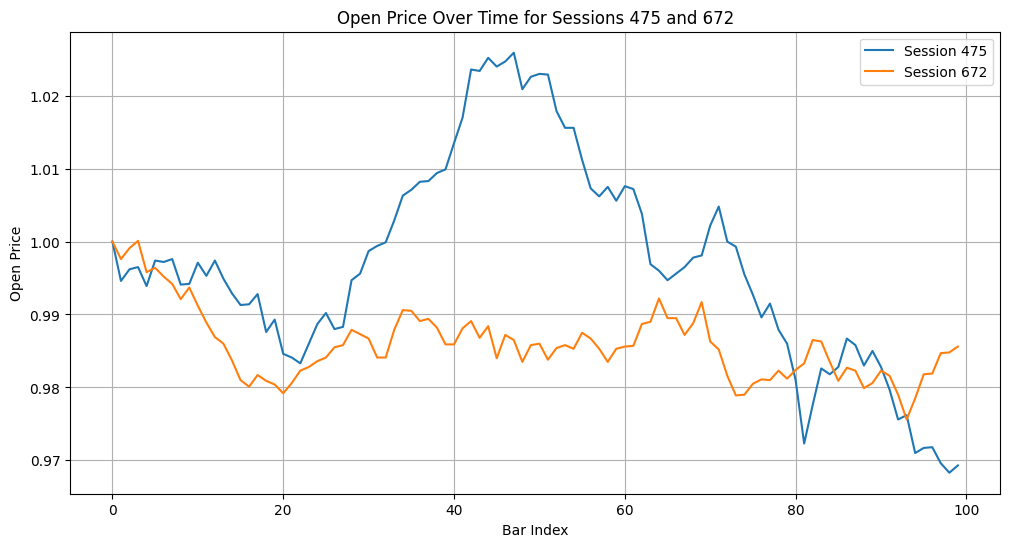

In [55]:
# plot session 475 and 672
plt.figure(figsize=(12, 6))
plt.plot(open_price_pivot.index, open_price_pivot[475], label="Session 475")
plt.plot(open_price_pivot.index, open_price_pivot[672], label="Session 672")
plt.title("Open Price Over Time for Sessions 475 and 672")
plt.xlabel("Bar Index")
plt.ylabel("Open Price")
plt.legend()
plt.grid()
plt.show()

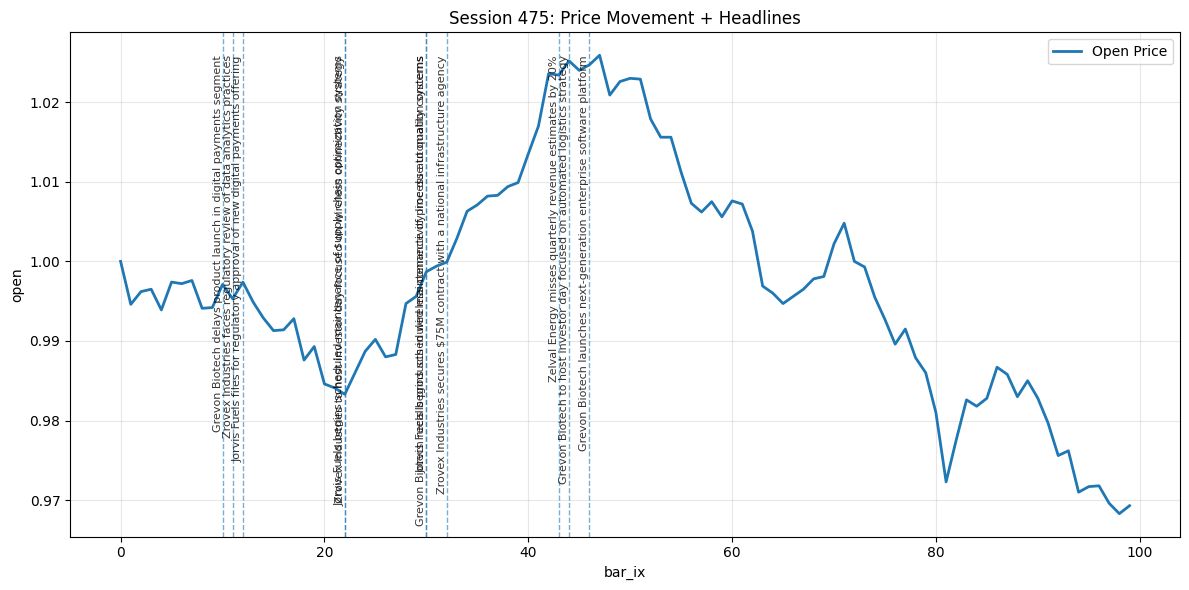

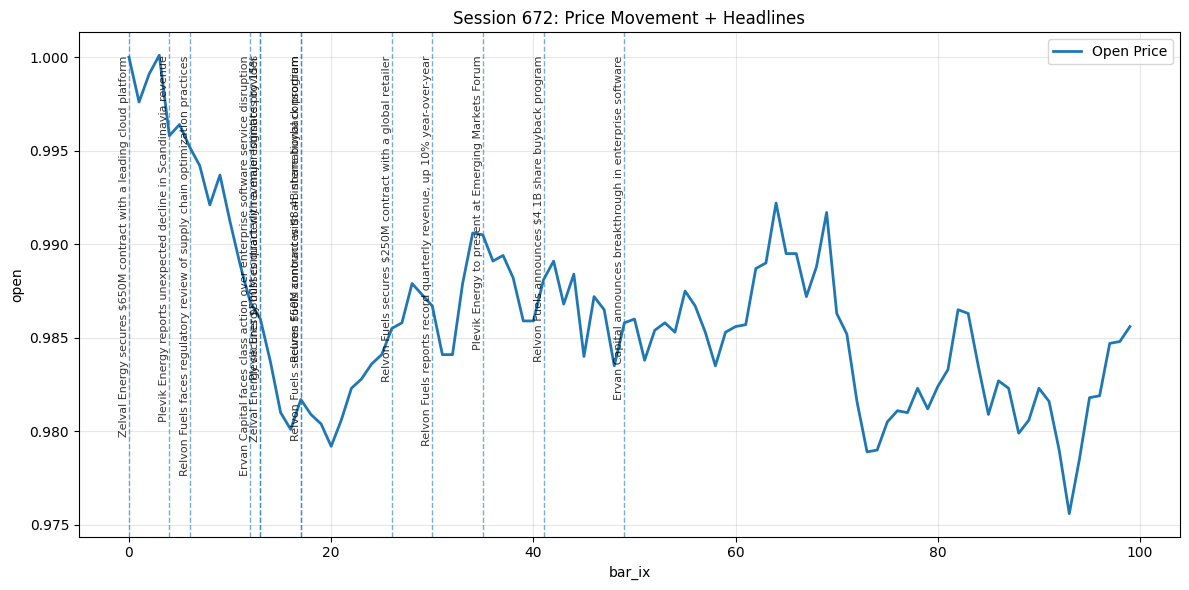

In [56]:
from tools import plot_session_with_news
"""
    Plot price movement for a given session with vertical lines for headlines.

    Parameters
    ----------
    bars_df : pd.DataFrame
        Must contain columns:
        ['session', 'bar_ix', 'open', 'high', 'low', 'close']

    headlines_df : pd.DataFrame
        Must contain columns:
        ['session', 'headline', 'bar_ix']

    session_n : int
        Session number to plot.

    price_col : str
        Which price column to plot ('open', 'high', 'low', 'close').

    figsize : tuple
        Figure size.

    show_headlines : bool
        If True, annotate headlines on chart.

    rotate_labels : int
        Rotation angle for headline labels.
"""
plot_session_with_news(
    bars_seen_train,
    headlines_seen_train,
    session_n=475,
    price_col="open",
    figsize=(12, 6),
    show_headlines=True,
)
plot_session_with_news(
    bars_seen_train,
    headlines_seen_train,
    session_n=672,
    price_col="open",
    figsize=(12, 6),
    show_headlines=True,
)

In [57]:
# Read the news for session 475 and 672
news_475 = headlines_seen_train[headlines_seen_train["session"] == 475]
news_672 = headlines_seen_train[headlines_seen_train["session"] == 672]

print("News for Session 475:")
print(news_475[["bar_ix", "headline"]].to_string(index=False))

print("\nNews for Session 672:")
print(news_672[["bar_ix", "headline"]].to_string(index=False))


News for Session 475:
 bar_ix                                                                              headline
     10                      Grevon Biotech delays product launch in digital payments segment
     11                 Zrovex Industries faces regulatory review of data analytics practices
     12           Jorvis Fuels files for regulatory approval of new digital payments offering
     22        Jorvis Fuels begins scheduled maintenance of supply chain optimization systems
     22      Zrovex Industries to host investor day focused on wireless connectivity strategy
     30               Jorvis Fuels begins scheduled maintenance of process automation systems
     30 Grevon Biotech recalls products in wireless connectivity line due to quality concerns
     32         Zrovex Industries secures $75M contract with a national infrastructure agency
     43                               Zelval Energy misses quarterly revenue estimates by 20%
     44           Grevon Biotech to ho

# VAR Factor Model: Zelval Energy vs Relvon Fuels (Beta-Neutral Pairs)

**Two synthetic instruments** — one per company — built by averaging price across their respective sessions:
- **Z[t]** = mean log-return at bar *t* across all Zelval-only sessions  
- **R[t]** = mean log-return at bar *t* across all Relvon-only sessions  

A VAR captures their dynamic relationship. Beta (hedge ratio) comes from OLS of cumulative Z on cumulative R.  
The **cointegration spread** `Z_cum − β·R_cum` is the pair's equilibrium: when it deviates, we mean-revert.

**Beta-neutral trade logic:**
- Spread > mean → Zelval over-performed → SHORT Zelval sessions, LONG Relvon sessions  
- Spread < mean → Zelval under-performed → LONG Zelval sessions, SHORT Relvon sessions  
- Individual session sizing scaled by idiosyncratic deviation from its own factor mean.

Zelval-only: 50  |  Relvon-only: 52  |  Both: 8


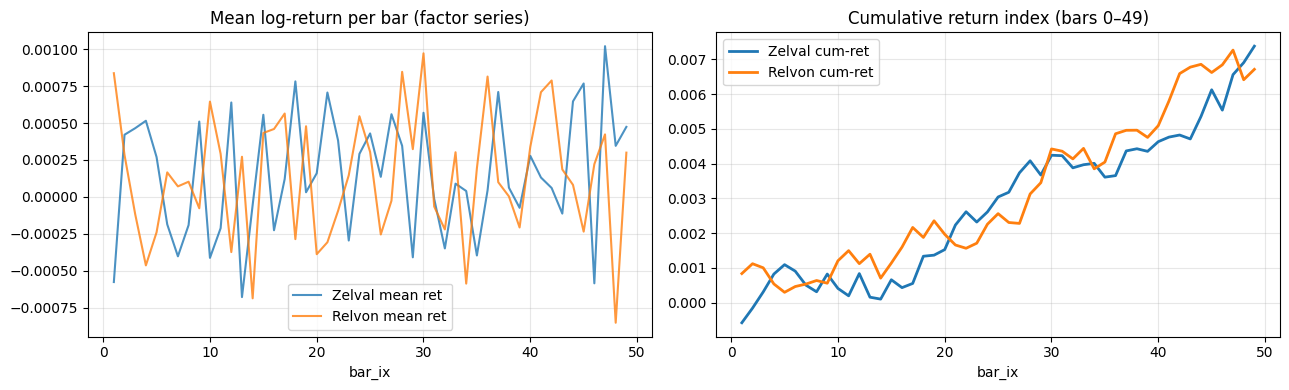

In [58]:
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import coint
from backtester import backtest

zelval_sids = set(headlines_seen_train[headlines_seen_train["headline"].str.contains("Zelval Energy", na=False)]["session"].unique())
relvon_sids = set(headlines_seen_train[headlines_seen_train["headline"].str.contains("Relvon Fuels",  na=False)]["session"].unique())

zelval_only = zelval_sids - relvon_sids
relvon_only = relvon_sids - zelval_sids
both        = zelval_sids & relvon_sids

print(f"Zelval-only: {len(zelval_only)}  |  Relvon-only: {len(relvon_only)}  |  Both: {len(both)}")

price_pivot = (
    bars_seen_train[bars_seen_train["bar_ix"] <= 49]
    .pivot(index="session", columns="bar_ix", values="close")
)
log_ret = np.log(price_pivot / price_pivot.shift(1, axis=1)).iloc[:, 1:]

Z_mean = log_ret.loc[log_ret.index.isin(zelval_only)].mean(axis=0)
R_mean = log_ret.loc[log_ret.index.isin(relvon_only)].mean(axis=0)
Z_cum  = Z_mean.cumsum()
R_cum  = R_mean.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Z_mean.index, Z_mean.values, label="Zelval mean ret", alpha=0.8)
axes[0].plot(R_mean.index, R_mean.values, label="Relvon mean ret", alpha=0.8)
axes[0].set_title("Mean log-return per bar (factor series)")
axes[0].set_xlabel("bar_ix"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(Z_cum.index, Z_cum.values, label="Zelval cum-ret", lw=2)
axes[1].plot(R_cum.index, R_cum.values, label="Relvon cum-ret", lw=2)
axes[1].set_title("Cumulative return index (bars 0–49)")
axes[1].set_xlabel("bar_ix"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 18, Apr, 2026
Time:                     13:31:08
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -31.0533
Nobs:                     49.0000    HQIC:                  -31.1012
Log likelihood:           625.642    FPE:                3.02122e-14
AIC:                     -31.1305    Det(Omega_mle):     2.90158e-14
--------------------------------------------------------------------
Results for equation Zelval
           coefficient       std. error           t-stat            prob
------------------------------------------------------------------------
const         0.000151         0.000059            2.559           0.011

Results for equation Relvon
           coefficient       std. error           t-stat            prob
--------------------------------------------------------------

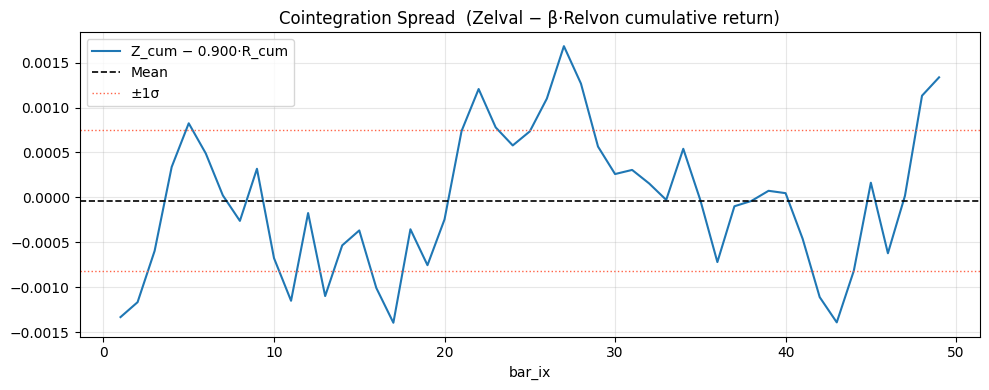

In [59]:
# ── VAR model on the two mean return series ───────────────────────────────
var_df     = pd.DataFrame({"Zelval": Z_mean.values, "Relvon": R_mean.values})
var_result = VAR(var_df).fit(maxlags=5, ic="aic")
print(var_result.summary())

# Granger causality only makes sense when lag > 0
if var_result.k_ar > 0:
    print("\n--- Granger causality: Relvon → Zelval ---")
    print(var_result.test_causality("Zelval", "Relvon", kind="f").summary())
else:
    print("\nVAR selected 0 lags — no dynamic lead-lag relationship detected.")
    print("Beta is still estimated from the contemporaneous covariance below.")

# ── Beta (hedge ratio) from OLS on cumulative returns ────────────────────
X_ols      = sm.add_constant(R_cum.values)
ols_coint  = sm.OLS(Z_cum.values, X_ols).fit()
beta_hedge = ols_coint.params[1]
print(f"\nHedge ratio β = {beta_hedge:.4f}  →  long 1 Zelval, short {beta_hedge:.4f} Relvon")

# ── Engle-Granger cointegration test ─────────────────────────────────────
coint_t, coint_p, _ = coint(Z_cum.values, R_cum.values)
print(f"Cointegration p-value: {coint_p:.4f}  {'✓ mean-reverting spread' if coint_p < 0.10 else '✗ spread may be non-stationary'}")

# ── Cointegration spread ──────────────────────────────────────────────────
spread_series = Z_cum - beta_hedge * R_cum
spread_mean   = spread_series.mean()
spread_std    = spread_series.std()

plt.figure(figsize=(10, 4))
plt.plot(spread_series.index, spread_series.values, label=f"Z_cum − {beta_hedge:.3f}·R_cum")
plt.axhline(spread_mean,                color="k",      ls="--", lw=1.2, label="Mean")
plt.axhline(spread_mean + spread_std,   color="tomato", ls=":",  lw=1,   label="±1σ")
plt.axhline(spread_mean - spread_std,   color="tomato", ls=":",  lw=1)
plt.title("Cointegration Spread  (Zelval − β·Relvon cumulative return)")
plt.xlabel("bar_ix"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [60]:
Z_perf = Z_cum.iloc[-1]
R_perf = R_cum.iloc[-1]
spread_at_49  = Z_perf - beta_hedge * R_perf
spread_zscore = (spread_at_49 - spread_mean) / spread_std

print(f"Factor spread at bar 49 : {spread_at_49:+.6f}")
print(f"Spread z-score          : {spread_zscore:+.3f}")
print("→ " + ("Zelval OVER-performed  ⟹  SHORT Zelval, LONG Relvon"
               if spread_zscore > 0 else
               "Zelval UNDER-performed  ⟹  LONG Zelval, SHORT Relvon"))

macro_z    = -np.sign(spread_zscore)
macro_r    =  np.sign(spread_zscore)
sign_scale =  np.sign(beta_hedge) if abs(beta_hedge) > 1e-6 else 1.0

session_cumret = np.log(price_pivot.iloc[:, -1] / price_pivot.iloc[:, 0])

is_z = session_cumret.index.isin(zelval_sids)
is_r = session_cumret.index.isin(relvon_sids)
ret  = session_cumret[is_z | is_r]
is_z_m, is_r_m = is_z[is_z | is_r], is_r[is_z | is_r]

vol = np.where(
    is_z_m & is_r_m,
    -np.sign(ret - (Z_perf + R_perf) / 2),
    np.where(
        is_z_m,
        np.sign(macro_z - np.sign(ret - Z_perf)),
        np.sign(macro_r - np.sign(ret - R_perf)) * sign_scale,
    ),
)

predictions = pd.DataFrame({"session": ret.index, "volume": vol.astype(float)})

print(f"\nPositions  — long: {(predictions['volume']>0).sum()}"
      f"  short: {(predictions['volume']<0).sum()}"
      f"  flat: {(predictions['volume']==0).sum()}")

z_notional = predictions[predictions["session"].isin(zelval_only)]["volume"].sum()
r_notional = predictions[predictions["session"].isin(relvon_only)]["volume"].sum()
net_beta   = z_notional + beta_hedge * r_notional
print(f"\nBeta-neutrality check:")
print(f"  Zelval notional    : {z_notional:+.1f}")
print(f"  Relvon notional    : {r_notional:+.1f}  (beta-adj: {beta_hedge * r_notional:+.3f})")
print(f"  Net beta exposure  : {net_beta:+.3f}  (ideal = 0)")

Factor spread at bar 49 : +0.001336
Spread z-score          : +1.742
→ Zelval OVER-performed  ⟹  SHORT Zelval, LONG Relvon

Positions  — long: 28  short: 30  flat: 52

Beta-neutrality check:
  Zelval notional    : -27.0
  Relvon notional    : +23.0  (beta-adj: +20.705)
  Net beta exposure  : -6.295  (ideal = 0)


  Sessions evaluated : 110
  Sharpe ratio       : +2.7397
  Mean PnL           : +0.002899
  Std  PnL           : 0.016928
  Win rate           : 29.09%

PnL breakdown by group:
                 mean       std  count
group                                 
Both         0.006035  0.025338      8
Relvon-only  0.004515  0.015736     52
Zelval-only  0.000715  0.016695     50


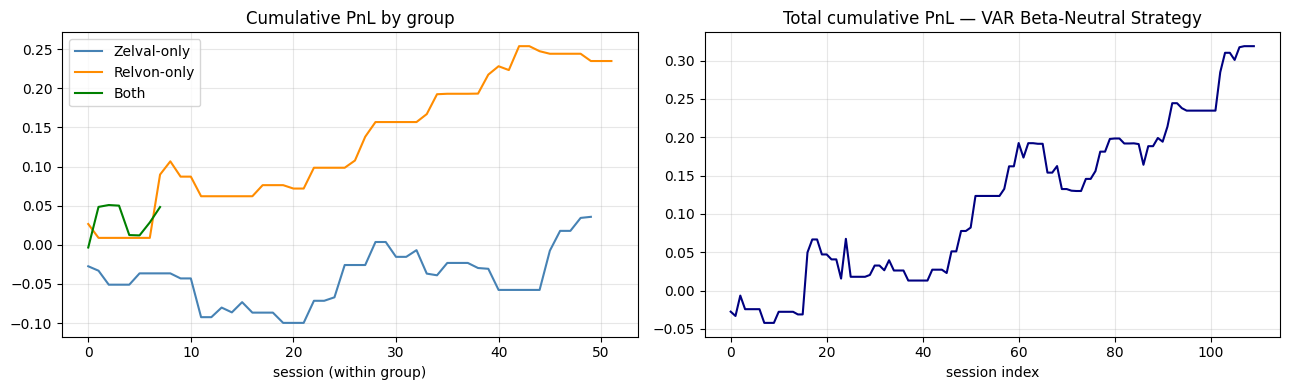

In [61]:
results = backtest(predictions)

results["group"] = np.select(
    [results["session"].isin(zelval_only), results["session"].isin(relvon_only)],
    ["Zelval-only", "Relvon-only"],
    default="Both",
)

print("\nPnL breakdown by group:")
print(results.groupby("group")["pnl"].agg(["mean", "std", "count"]).round(6))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for grp, color in [("Zelval-only", "steelblue"), ("Relvon-only", "darkorange"), ("Both", "green")]:
    sub = results[results["group"] == grp].sort_values("session")["pnl"].reset_index(drop=True)
    axes[0].plot(sub.cumsum(), label=grp, color=color)
axes[0].set_title("Cumulative PnL by group"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel("session (within group)")

results.sort_values("session")["pnl"].reset_index(drop=True).cumsum().plot(ax=axes[1], color="navy")
axes[1].set_title("Total cumulative PnL — VAR Beta-Neutral Strategy")
axes[1].grid(alpha=0.3); axes[1].set_xlabel("session index")

plt.tight_layout(); plt.show()

In [64]:
pharma_cluster = [
"Calvis Sciences",
"Calvos Genomics",
"Frelis Genomics",
"Grevel Diagnostics",
"Grevon Biotech",
"Jorvix Diagnostics",
"Krevum Pharmaceuticals",
"Myrnon Therapeutics",
"Nerval Biopharma",
"Relvos Biosciences",
"Wyrnik Sciences",
"Xelvol Biotech",
"Yorvov Pharmaceuticals",
"Zelvix Therapeutics",
"Zelvon Biosciences",
"Zrovum Biopharma"]

energy_cluster = [
"Jorvis Fuels",
"Kelvik Power",
"Kelvos Resources",
"Nerven Grid",
"Nolvol Resources",
"Orevex Renewables",
"Orevov Solutions",
"Plevep Power",
"Plevik Energy",
"Relvon Fuels",
"Strynal Industries",
"Ulvon Renewables",
"Urvel Grid",
"Wyrnor Solutions",
"Zelval Energy",
"Zrovex Industries"]

commerce_cluster = [
"Arnik Commerce",
"Arnos Marketplace",
"Crevol Retail",
"Frelex Outlets",
"Halvav Brands",
"Holtar Stores",
"Ixenis Outlets",
"Jorval Trading",
"Joval Brands",
"Nolvav Commerce",
"Orevar Marketplace",
"Pleven Trading",
"Talvyn Goods",
"Varvov Retail",
"Xovep Stores",
"Xovol Goods"]

money_cluster = [
"Creven Securities",
"Ervan Capital",
"Halven Investments",
"Halvix Holdings",
"Holtum Asset",
"Ilval Financial",
"Jorvyl Securities",
"Jovik Asset",
"Krevan Investments",
"Plevum Partners",
"Plevyl Advisors",
"Talvix Holdings",
"Wrelal Financial",
"Yorval Partners",
"Zelvel Capital",
"Zrovov Advisors"]

hardware_cluster = [
"Brevep Systems",
"Brevon Microchips",
"Crevex Labs",
"Dralol Computing",
"Frelol Software",
"Halvax Networks",
"Ixenix Technologies",
"Jovor Networks",
"Myrnep Technologies",
"Nolvis Devices",
"Prynis Systems",
"Relvan Software",
"Talvep Computing",
"Ulvyn Microchips",
"Volval Devices",
"Yorven Labs"
]

In [70]:
# Get all sessions in the pharma cluster

pharma_sessions = headlines_seen_train[headlines_seen_train["headline"].str.contains("|".join(pharma_cluster), na=False)]["session"].unique()
pharma = bars_seen_train[bars_seen_train["session"].isin(pharma_sessions)]
